In [1]:
from pathlib import Path

import numpy as np
import awkward as ak
import uproot
import vector
import matplotlib.pyplot as plt

vector.register_awkward()

In [2]:
ROOT_FILE_EE = Path("../data/Run2012B_DoubleElectron.root")

assert ROOT_FILE_EE.exists(), f"File not found: {ROOT_FILE_EE.resolve()}"

f_ee = uproot.open(ROOT_FILE_EE)
events_ee = f_ee["Events"]

print("File:", ROOT_FILE_EE.resolve())
print("Number of events:", events_ee.num_entries)

electron_branches = [k for k in events_ee.keys() if "Electron" in k]
electron_branches[:30]

File: C:\Users\AhrixMarin\Desktop\otus\experiments\cms_zpeak\data\Run2012B_DoubleElectron.root
Number of events: 21474287


['nElectron',
 'Electron_pt',
 'Electron_eta',
 'Electron_phi',
 'Electron_mass',
 'Electron_charge',
 'Electron_pfRelIso03_all',
 'Electron_dxy',
 'Electron_dxyErr',
 'Electron_dz',
 'Electron_dzErr']

In [3]:
branches_ee = [
    "nElectron",
    "Electron_pt",
    "Electron_eta",
    "Electron_phi",
    "Electron_mass",
    "Electron_charge",
    "Electron_pfRelIso03_all",
    "Electron_dxy",
    "Electron_dxyErr",
    "Electron_dz",
    "Electron_dzErr",
]

arrays_ee = events_ee.arrays(branches_ee, library="ak")

print("Loaded events:", len(arrays_ee["nElectron"]))
print("Example nElectron values:", arrays_ee["nElectron"][:10])

Loaded events: 21474287
Example nElectron values: [0, 1, 2, 2, 1, 2, 0, 2, 1, 0]


In [4]:
# Basic kinematic cuts
electron_pt_min = 20.0
electron_abs_eta_max = 2.5

# Electron quality cuts
electron_iso_max = 0.15
electron_dxy_max = 0.05
electron_dz_max = 0.10

# Build electron Lorentz-vector objects
electrons = ak.zip(
    {
        "pt": arrays_ee["Electron_pt"],
        "eta": arrays_ee["Electron_eta"],
        "phi": arrays_ee["Electron_phi"],
        "mass": arrays_ee["Electron_mass"],
        "charge": arrays_ee["Electron_charge"],
        "pfRelIso03_all": arrays_ee["Electron_pfRelIso03_all"],
        "dxy": arrays_ee["Electron_dxy"],
        "dxyErr": arrays_ee["Electron_dxyErr"],
        "dz": arrays_ee["Electron_dz"],
        "dzErr": arrays_ee["Electron_dzErr"],
    },
    with_name="Momentum4D",
)

abs_eta = np.abs(electrons.eta)

# ECAL barrel/endcap transition gap veto
# This region is usually avoided for electrons.
outside_ecal_gap = ~((abs_eta > 1.4442) & (abs_eta < 1.566))

# Select good electron candidates
selected_electrons = electrons[
    (electrons.pt > electron_pt_min)
    & (abs_eta < electron_abs_eta_max)
    & outside_ecal_gap
    & (electrons.pfRelIso03_all < electron_iso_max)
    & (np.abs(electrons.dxy) < electron_dxy_max)
    & (np.abs(electrons.dz) < electron_dz_max)
]

print("Total selected electrons:", ak.sum(ak.num(selected_electrons)))
print("Events with >=2 selected electrons:", ak.sum(ak.num(selected_electrons) >= 2))

# Make all possible electron pairs inside each event
pairs_ee = ak.combinations(
    selected_electrons,
    2,
    fields=["e1", "e2"],
)

# Keep opposite-sign e+e- pairs
os_pairs_ee = pairs_ee[
    (pairs_ee.e1.charge * pairs_ee.e2.charge) < 0
]

print("Opposite-sign dielectron pairs:", ak.sum(ak.num(os_pairs_ee)))

# Compute invariant mass
m_ee = (os_pairs_ee.e1 + os_pairs_ee.e2).mass
m_ee = ak.flatten(m_ee)

# Keep the Z-window
masses_ee_z = m_ee[
    (m_ee > 70)
    & (m_ee < 110)
]

masses_ee_z = ak.to_numpy(masses_ee_z)

print("Total selected opposite-sign dielectron pairs in 70-110 GeV:", len(masses_ee_z))
print(f"Mean mass:   {np.mean(masses_ee_z):.6f} GeV")
print(f"Median mass: {np.median(masses_ee_z):.6f} GeV")

# Find peak bin
bins = np.linspace(70, 110, 81)
counts, edges = np.histogram(masses_ee_z, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])

peak_idx = np.argmax(counts)

print(f"Peak bin center: {centers[peak_idx]:.2f} GeV")
print(f"Peak bin count:  {counts[peak_idx]}")

Total selected electrons: 9734445
Events with >=2 selected electrons: 1903393
Opposite-sign dielectron pairs: 1639419
Total selected opposite-sign dielectron pairs in 70-110 GeV: 1344681
Mean mass:   90.638107 GeV
Median mass: 91.148415 GeV
Peak bin center: 91.75 GeV
Peak bin count:  75582


Saved to ..\figures\cms_ee_zpeak_70_110GeV.png
Histogram peak bin center = 91.75 GeV


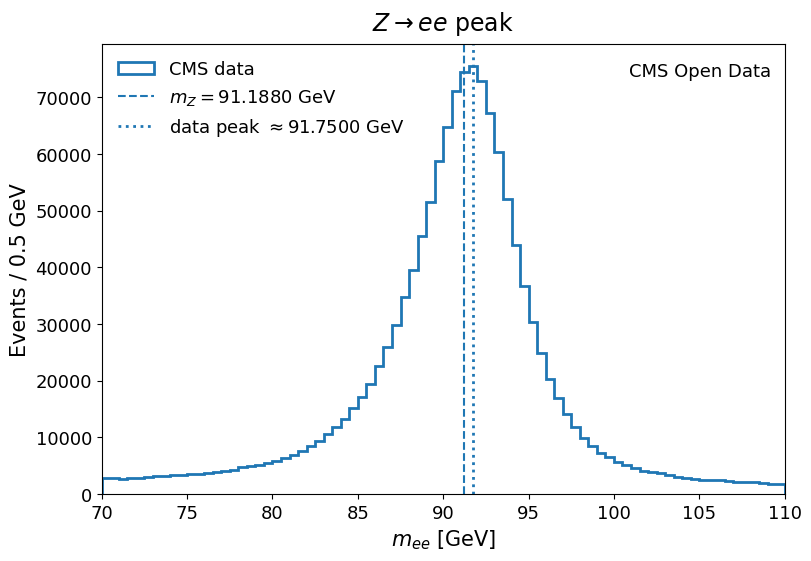

In [5]:
fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)

bins = np.linspace(70, 110, 81)
bin_width = bins[1] - bins[0]

counts, edges = np.histogram(masses_ee_z, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])
peak_mass = centers[np.argmax(counts)]

ax.hist(
    masses_ee_z,
    bins=bins,
    histtype="step",
    linewidth=2,
    label="CMS data",
)

ax.axvline(
    91.1880,
    linestyle="--",
    linewidth=1.5,
    label=r"$m_Z = 91.1880$ GeV",
)

ax.axvline(
    peak_mass,
    linestyle=":",
    linewidth=2.0,
    label=fr"data peak $\approx {peak_mass:.4f}$ GeV",
)

ax.set_xlabel(r"$m_{ee}$ [GeV]", fontsize=15)
ax.set_ylabel(f"Events / {bin_width:.1f} GeV", fontsize=15)
ax.set_xlim(70, 110)
ax.tick_params(axis="both", labelsize=13)

ax.set_title(r"$Z\to ee$ peak", fontsize=17, pad=10)

ax.legend(
    loc="upper left",
    frameon=False,
    fontsize=13,
)

ax.text(
    0.98, 0.96,
    "CMS Open Data",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=13,
)

out = Path("../figures/cms_ee_zpeak_70_110GeV.png")
fig.savefig(out, dpi=200)
print(f"Saved to {out}")
print(f"Histogram peak bin center = {peak_mass:.2f} GeV")

Saved to ..\figures\cms_ee_zpeak_70_110GeV_normalized.png


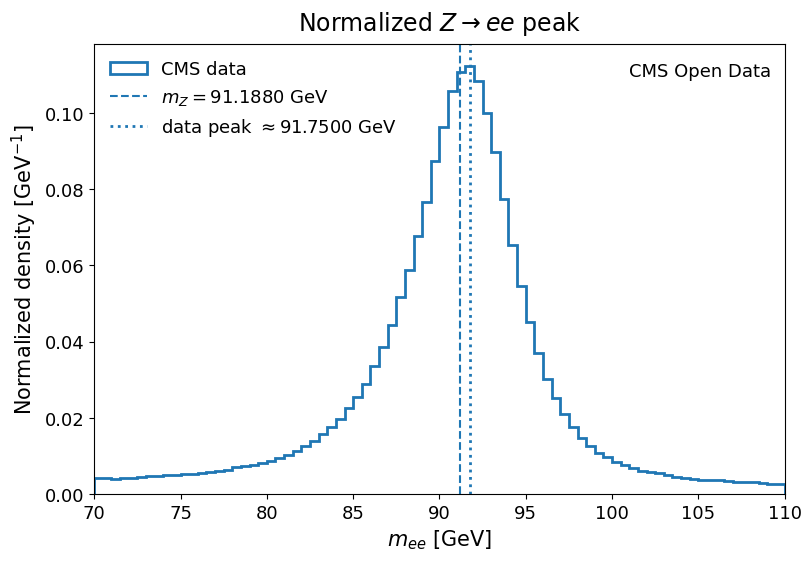

In [6]:
fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)

bins = np.linspace(70, 110, 81)

ax.hist(
    masses_ee_z,
    bins=bins,
    histtype="step",
    linewidth=2,
    density=True,
    label="CMS data",
)

ax.axvline(
    91.1880,
    linestyle="--",
    linewidth=1.5,
    label=r"$m_Z = 91.1880$ GeV",
)

ax.axvline(
    peak_mass,
    linestyle=":",
    linewidth=2.0,
    label=fr"data peak $\approx {peak_mass:.4f}$ GeV",
)

ax.set_xlabel(r"$m_{ee}$ [GeV]", fontsize=15)
ax.set_ylabel(r"Normalized density [GeV$^{-1}$]", fontsize=15)
ax.set_xlim(70, 110)

ax.tick_params(axis="both", labelsize=13)

ax.set_title(r"Normalized $Z\to ee$ peak", fontsize=17, pad=10)

ax.legend(
    loc="upper left",
    frameon=False,
    fontsize=13,
)

ax.text(
    0.98, 0.96,
    "CMS Open Data",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=13,
)

out = Path("../figures/cms_ee_zpeak_70_110GeV_normalized.png")
fig.savefig(out, dpi=200)
print(f"Saved to {out}")

In [7]:
masses_ee_near_z = masses_ee_z[(masses_ee_z > 86) & (masses_ee_z < 96)]

print("Full 70-110 GeV window")
print(f"Mean:   {np.mean(masses_ee_z):.3f} GeV")
print(f"Median: {np.median(masses_ee_z):.3f} GeV")

print("\nNear-Z 86-96 GeV window")
print(f"Mean:   {np.mean(masses_ee_near_z):.3f} GeV")
print(f"Median: {np.median(masses_ee_near_z):.3f} GeV")

Full 70-110 GeV window
Mean:   90.638 GeV
Median: 91.148 GeV

Near-Z 86-96 GeV window
Mean:   91.211 GeV
Median: 91.317 GeV
